In [2]:
import pandas as pd
data=pd.read_csv("health care diabetes (1).csv")
x=data.iloc[:,:-1].to_numpy()
y=data.iloc[:,-1].to_numpy()
# x=x[0:15]

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



theta = np.zeros(x.shape[1])
bias = 0
epoch_list=[]
train_loss=[]
train_accuracy=[]
val_accuracy=[]
val_loss=[]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.125, random_state=1)
y_final_pred=0
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid2(z):
    f= 1 / (1 + np.exp(-z))
    x=[]
    for i in f:
      if i>=0.5:
          x.append(1)
      else:
        x.append(0)
    return x

def cross_entropy_loss(y_pred,y_i):
    epsilon = 1e-10  # small constant to prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = - np.mean(y_i * np.log(y_pred) + (1 - y_i) * np.log(1 - y_pred))
    return loss

def accuracy(x_i,y_i):
    global theta,bias
    n=len(x_i)
    z = np.dot(x_i, theta) + bias
    y_pred = sigmoid2(z)
    t=0
    for i in range(n):
      if y_i[i]==y_pred[i]:
        t+=1
    return t/n


def logistic(learnrate,penalty,alpha=0.1):
    global theta,bias,epoch_list,train_loss,train_accuracy,val_accuracy,val_loss,x_train,y_train,x_val,y_val,x_test,y_test,y_final_pred
    theta = np.zeros(x.shape[1])
    bias = 0
    epoch_list=[]
    train_loss=[]
    train_accuracy=[]
    val_accuracy=[]
    val_loss=[]
    learning_rate = learnrate
    epochs = 50



    # Perform Stochastic Gradient Descent
    for epoch in range(epochs):
        cur_train_loss=0
        cur_var_loss=0
        epoch_list.append(epoch+1)
        for i in range(len(x)):

            # Select a random data point
            random_index = np.random.randint(0, len(x_train))
            x_i = x_train[random_index]
            y_i = y_train[random_index]

            # Compute the prediction
            z = np.dot(x_i, theta) + bias
            y_pred = sigmoid(z)
            # Compute the gradient of the loss
            gradient = (y_pred-y_i)

            if penalty == 'l1':
                l1_penalty = alpha * np.sign(theta)
                theta -= learning_rate * (gradient + l1_penalty)
            elif penalty == 'l2':
                l2_penalty =alpha *theta
                theta -= learning_rate * (gradient + l2_penalty)
            else:
                theta -= learning_rate * gradient*x_i
            # Update weights and bias to minimize the loss
            bias -= learning_rate * gradient

        train_loss.append(cross_entropy_loss(y_pred,y_train))
        z = np.dot(x_val, theta) + bias
        y_pred = sigmoid(z)
        val_loss.append(cross_entropy_loss(y_pred,y_val))
        train_accuracy.append(accuracy(x_train,y_train))
        val_accuracy.append(accuracy(x_val,y_val))

    z = np.dot(x_test, theta) + bias
    y_pred = sigmoid(z)
    y_final_pred=sigmoid(np.dot(x_train, theta) + bias)
    test_loss=cross_entropy_loss(y_pred,y_test)
    print("test loss: ",test_loss)
    print("test accuracy: ",accuracy(x_test,y_test))

logistic(0.01,None)

<ipython-input-3-fc2bccfdd678>:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
<ipython-input-3-fc2bccfdd678>:21: RuntimeWarning: overflow encountered in exp
  f= 1 / (1 + np.exp(-z))


test loss:  6.793712945087064
test accuracy:  0.6883116883116883


In [4]:
#plots
import matplotlib.pyplot as plt
def loss(epoch_list,train_loss,val_loss):
  #Training vs iteration
  # fig = plt.figure(figsize =(20, 15))
  plt.plot(epoch_list,train_loss,label="Training Loss")
  plt.plot(epoch_list,val_loss,label="Validation Loss")
  plt.title("Training Loss , Validation Loss")
  plt.xlabel("Iteration")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()



In [5]:
#acuuracy
def accuracy2(epoch_list,train_accuracy,val_accuracy):
  plt.plot(epoch_list,train_accuracy,label="Training Accuracy")
  plt.plot(epoch_list,val_accuracy,label="Validation Accuracy")
  plt.title("Training Accuracy , Validation Accuracy")
  plt.xlabel("Iteration")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()


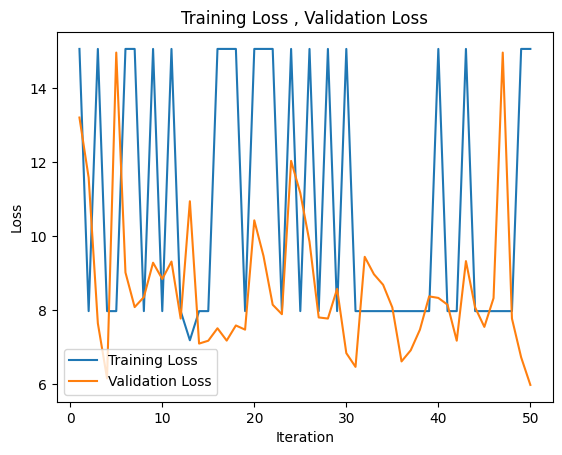

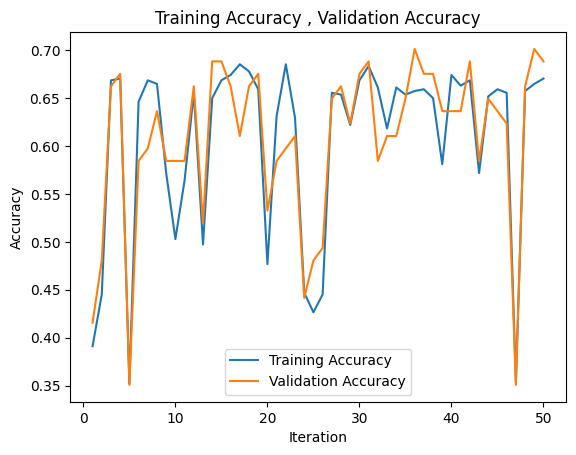

In [6]:
loss(epoch_list,train_loss,val_loss)
accuracy2(epoch_list,train_accuracy,val_accuracy)

<ipython-input-3-fc2bccfdd678>:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
<ipython-input-3-fc2bccfdd678>:21: RuntimeWarning: overflow encountered in exp
  f= 1 / (1 + np.exp(-z))


test loss:  12.410036501525012
test accuracy:  0.461038961038961


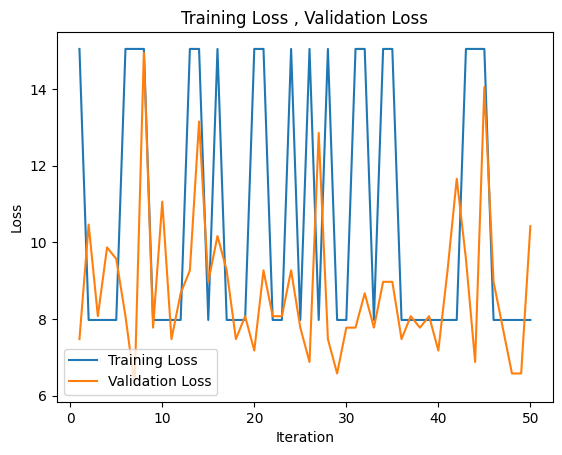

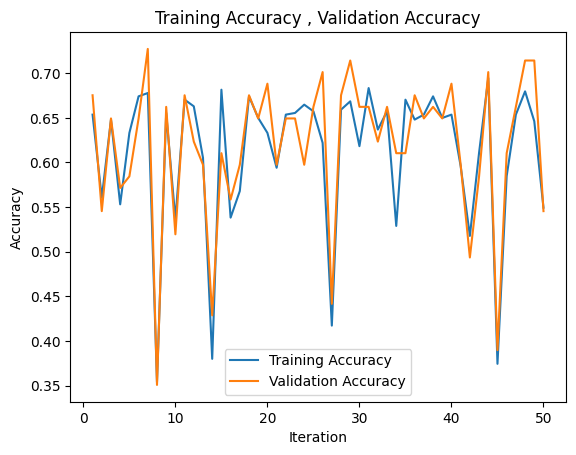

test loss:  13.9052216166311
test accuracy:  0.3961038961038961


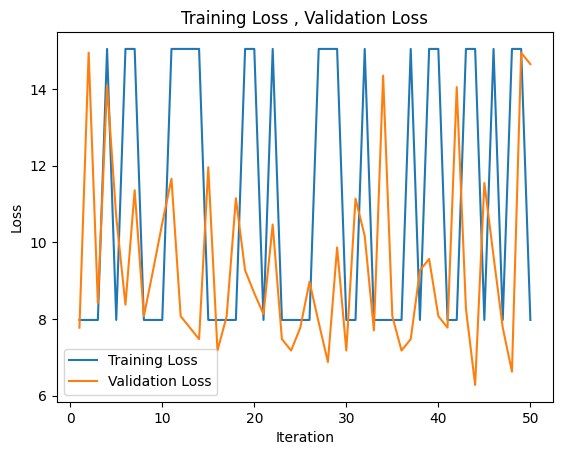

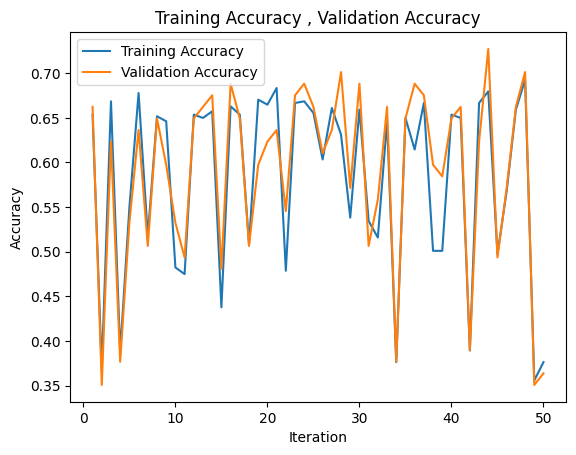

test loss:  8.775114000254439
test accuracy:  0.6168831168831169


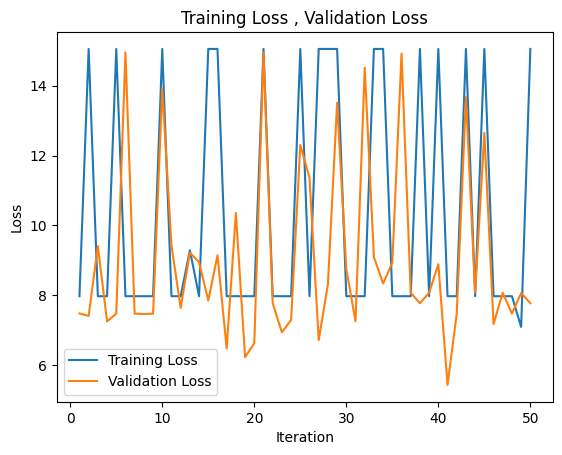

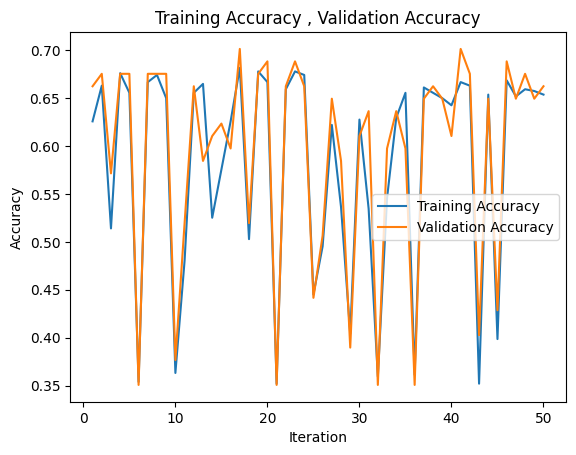

test loss:  7.267738360614002
test accuracy:  0.6168831168831169


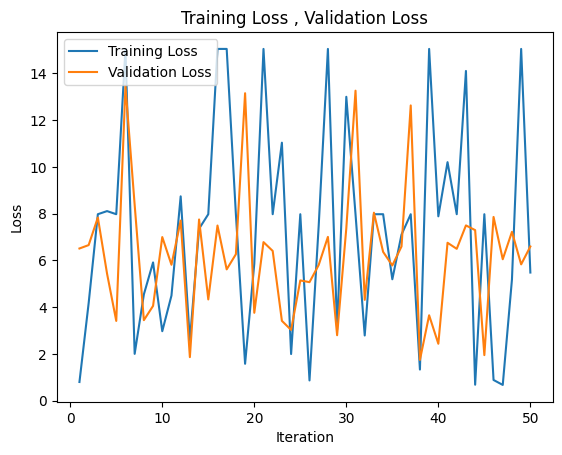

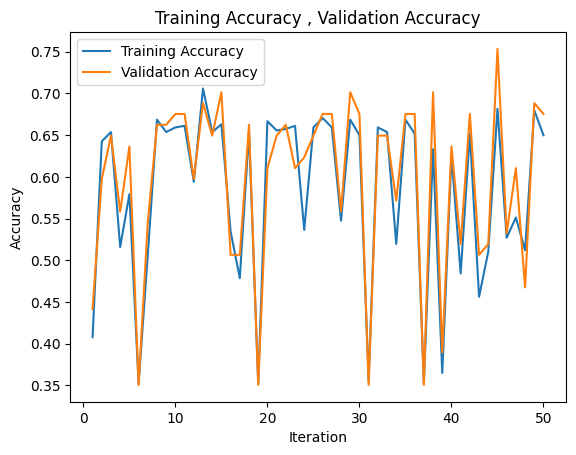

In [7]:
#different learning rates

#rate=1
logistic(1,None)
loss(epoch_list,train_loss,val_loss)
accuracy2(epoch_list,train_accuracy,val_accuracy)
#rate=0.1
logistic(0.1,None)
loss(epoch_list,train_loss,val_loss)
accuracy2(epoch_list,train_accuracy,val_accuracy)
#rate=0.01
logistic(0.01,None)
loss(epoch_list,train_loss,val_loss)
accuracy2(epoch_list,train_accuracy,val_accuracy)
#rate=0.001
logistic(0.001,None)
loss(epoch_list,train_loss,val_loss)
accuracy2(epoch_list,train_accuracy,val_accuracy)

<ipython-input-3-fc2bccfdd678>:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
<ipython-input-3-fc2bccfdd678>:21: RuntimeWarning: overflow encountered in exp
  f= 1 / (1 + np.exp(-z))


test loss:  8.522555306137422
test accuracy:  0.6298701298701299


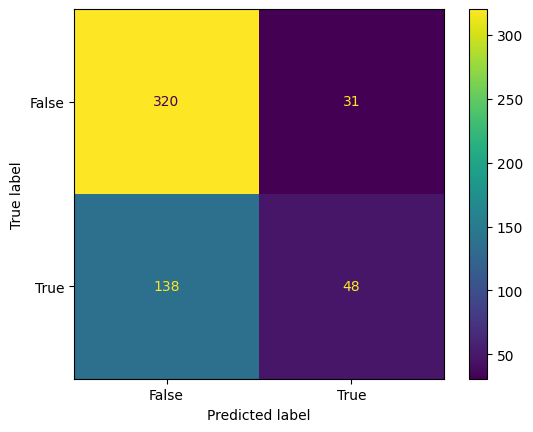

In [8]:
#confusion matrix
logistic(0.01,None)
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
for i in range(len(y_final_pred)):
  if y_final_pred[i]>=0.5:
    y_final_pred[i]=1
  else:
    y_final_pred[i]=0
cm=confusion_matrix(y_train, y_final_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [False, True])

cm_display.plot()
plt.show()

l1 alpha=  0.1
test loss:  5.281830259142579
test accuracy:  0.6428571428571429

l1 alpha=  0.01
test loss:  2.9482869360122885
test accuracy:  0.6428571428571429

l1 alpha=  1
test loss:  12.792590253918295
test accuracy:  0.35714285714285715

l1 alpha=  0.001
test loss:  4.296183852103423
test accuracy:  0.6428571428571429

l2 alpha=  0.1
test loss:  5.209427360534789
test accuracy:  0.6428571428571429

l2 alpha=  0.01
test loss:  5.736857079319042
test accuracy:  0.6428571428571429

l2 alpha=  1
test loss:  5.752820678684326
test accuracy:  0.6428571428571429

l2 alpha=  0.001
test loss:  6.540728589591392
test accuracy:  0.6428571428571429

best l1 aplha=0.01
test loss:  2.6041027511998522
test accuracy:  0.6428571428571429


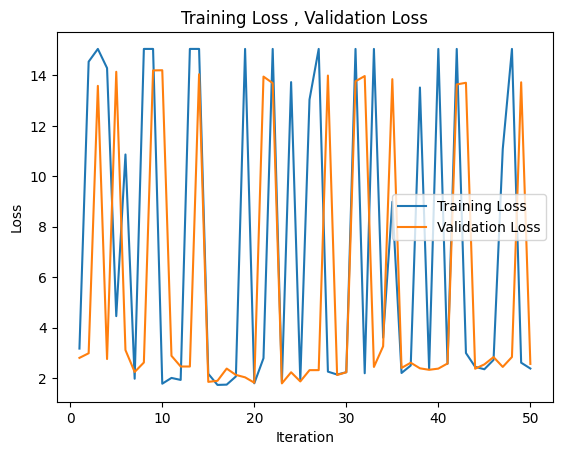

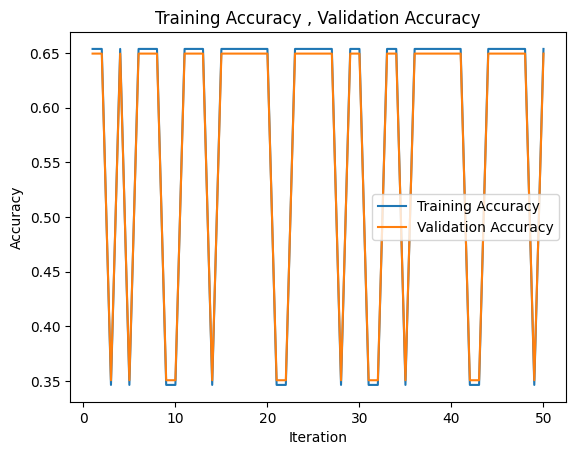


best l2 alpha=1
test loss:  12.93407829420315
test accuracy:  0.35714285714285715


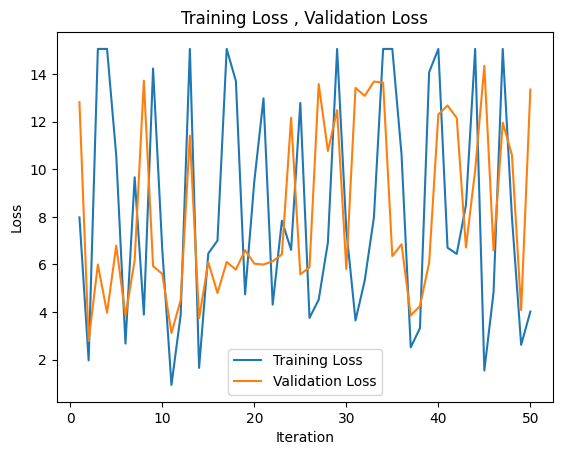

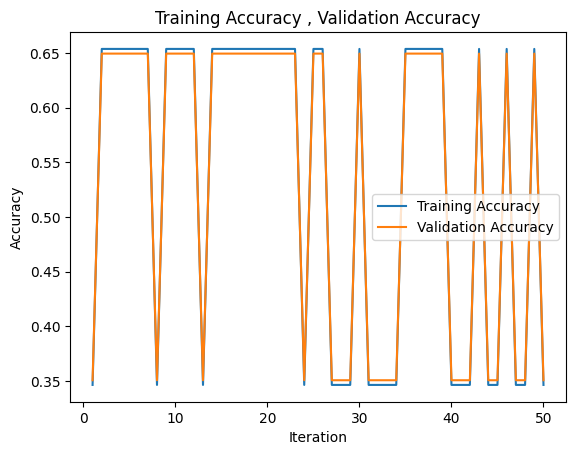

In [9]:
#l1 lasso
l=[0.1,0.01,1,0.001]
for i in l:
    print("l1 alpha= ",i)
    logistic(0.1,"l1",i)
    print()

#l2
for i in l:
  print("l2 alpha= ",i)
  logistic(0.1,"l2",i)
  print()

print("best l1 aplha=0.01")
logistic(0.1,"l1",0.01)
loss(epoch_list,train_loss,val_loss)
print()
accuracy2(epoch_list,train_accuracy,val_accuracy)
print()

print("best l2 alpha=1")
logistic(0.1,"l2",1)
loss(epoch_list,train_loss,val_loss)
print()
accuracy2(epoch_list,train_accuracy,val_accuracy)



<ipython-input-3-fc2bccfdd678>:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


test loss:  7.9378336700216545
test accuracy:  0.6298701298701299


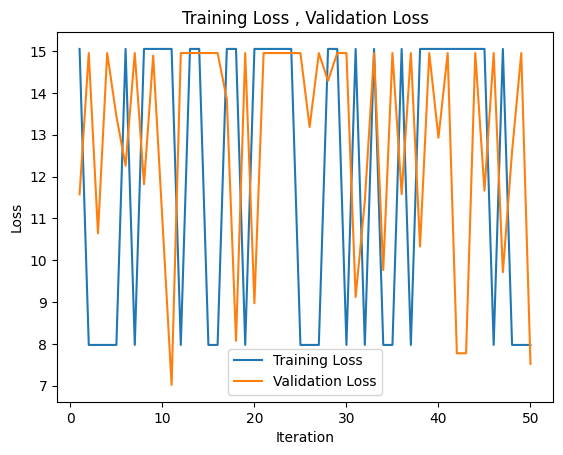

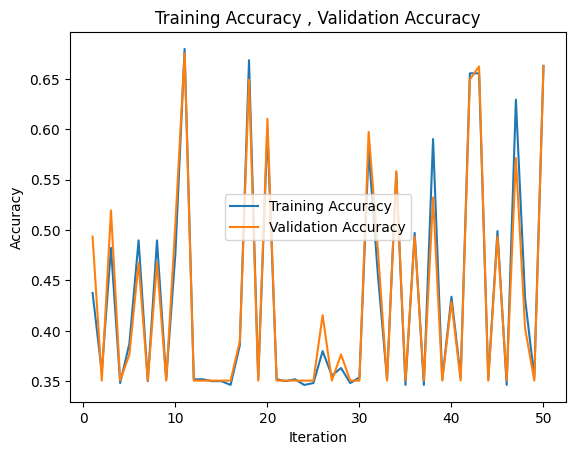

In [10]:
epoch_list2=[]
train_loss2=[]
train_accuracy2=[]
val_accuracy2=[]
val_loss2=[]
def sigtan(z):
    return np.tanh(z)

def sigtan2(z):
    f=np.tanh(z)
    x=[]
    for i in f:
      if i>=0.5:
          x.append(1)
      else:
        x.append(0)
    return x

def mse_loss(y_pred,y_i):
    return np.mean((y_pred-y_i)**2)

def accuracy(x_i,y_i):
    global theta,bias
    n=len(x_i)
    z = np.dot(x_i, theta) + bias
    y_pred = sigtan2(z)
    t=0
    for i in range(n):
      if y_i[i]==y_pred[i]:
        t+=1
    return t/n


def new_logistic(learnrate,penalty,alpha=0.1):
    global theta,bias,epoch_list2,train_loss2,train_accuracy2,val_accuracy2,val_loss2,x_train,y_train,x_val,y_val,x_test,y_test,y_final_pred
    theta = np.zeros(x.shape[1])
    bias = 0
    learning_rate = learnrate
    epochs = 50



    # Perform Stochastic Gradient Descent
    for epoch in range(epochs):
        cur_train_loss=0
        cur_var_loss=0
        epoch_list2.append(epoch+1)
        for i in range(len(x)):

            # Select a random data point
            random_index = np.random.randint(0, len(x_train))
            x_i = x_train[random_index]
            y_i = y_train[random_index]

            # Compute the prediction
            z = np.dot(x_i, theta) + bias
            y_pred = sigtan(z)
            # Compute the gradient of the loss
            gradient = (y_pred-y_i)

            if penalty == 'l1':
                l1_penalty = alpha * np.sign(theta)
                theta -= learning_rate * (gradient + l1_penalty)
            elif penalty == 'l2':
                l2_penalty =alpha *theta
                theta -= learning_rate * (gradient + l2_penalty)
            else:
                theta -= learning_rate * gradient*x_i
            # Update weights and bias to minimize the loss
            bias -= learning_rate * gradient

        train_loss2.append(cross_entropy_loss(y_pred,y_train))
        z = np.dot(x_val, theta) + bias
        y_pred = sigtan(z)
        val_loss2.append(cross_entropy_loss(y_pred,y_val))
        train_accuracy2.append(accuracy(x_train,y_train))
        val_accuracy2.append(accuracy(x_val,y_val))

    z = np.dot(x_test, theta) + bias
    y_pred = sigtan(z)
    y_final_pred=sigmoid(np.dot(x_train, theta) + bias)
    test_loss=cross_entropy_loss(y_pred,y_test)
    print("test loss: ",test_loss)
    print("test accuracy: ",accuracy(x_test,y_test))

new_logistic(0.01,None)
loss(epoch_list2,train_loss2,val_loss2)
accuracy2(epoch_list2,train_accuracy2,val_accuracy2)

In [14]:
#mini batch gradient descent
import numpy as np
from sklearn.model_selection import train_test_split



# Initialize model parameters (weights and bias)
theta = np.zeros(x.shape[1])
bias = 0
epoch_list=[]
train_loss=[]
train_accuracy=[]
val_accuracy=[]
val_loss=[]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.125, random_state=1)
batch_sizes=[10,20,30,40]
epochs=100
learning_rate=0.01
# Define the logistic loss function
def logistic_loss(y_pred,y_true):
    epsilon = 1e-10  # small constant to prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

for batch in batch_sizes:
# Training loop
  for epoch in range(epochs):
      # Shuffle the training data
      permutation = np.random.permutation(len(x_train))
      X_train_shuffled = x_train[permutation]
      y_train_shuffled = y_train[permutation]

      for i in range(0, len(x_train), batch):
          # Create a mini-batch
          X_batch = X_train_shuffled[i:i + batch]
          y_batch = y_train_shuffled[i:i + batch]

          # Forward pass
          z = np.dot(X_batch, theta) + bias
          a = 1 / (1 + np.exp(-z))

          # Compute the gradient
          gradient = np.dot(X_batch.T, (a - y_batch)) / len(X_batch)

          # Update the model parameters using mini-batch gradient descent
          theta -= learning_rate * gradient
          bias -= learning_rate * np.mean(a - y_batch)
      train_loss.append(logistic_loss(y_batch,y_train))
      z = np.dot(x_val, theta) + bias
      y_pred = sigmoid(z)
      val_loss.append(logistic_loss(y_batch,y_val))
      train_accuracy.append(accuracy(x_train,y_train))
      val_accuracy.append(accuracy(x_val,y_val))
  loss(epoch_list,train_loss,val_loss)
  print()
  accuracy2(epoch_list,train_accuracy,val_accuracy)


ValueError: ignored